In [2]:
import pandas as pd

# Load the dataset
file_path = "/content/glass.xlsx"

# Check available sheets
xls = pd.ExcelFile(file_path)
xls.sheet_names

# Load the description sheet
description_df = pd.read_excel(xls, sheet_name="Description")

# Display the first few rows of the description
description_df.head()



,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [3]:
# Load the Glass dataset
glass_df = pd.read_excel(xls, sheet_name="glass")

# Display basic information about the dataset
glass_df.info(), glass_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


(None,
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
 0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
 1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
 2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
 3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
 4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1)

# **Initial Observations:**
* The dataset contains 214 rows and 10 columns.
* There are 9 numerical features and 1 target variable (Type), which represents the type of glass.
* No missing values are present in the dataset.
* The features include chemical compositions such as Refractive Index (RI), Sodium (Na), Magnesium (Mg), Aluminum (Al), etc..

<ipython-input-4-9188da4895d2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=glass_df["Type"], palette="viridis")


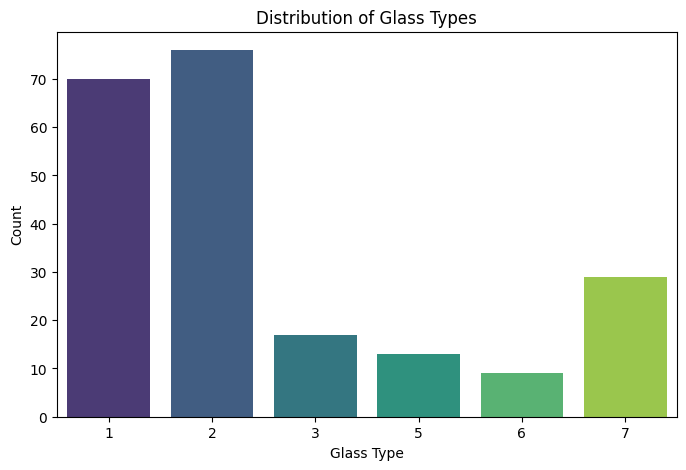

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=glass_df["Type"], palette="viridis")
plt.title("Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.show()


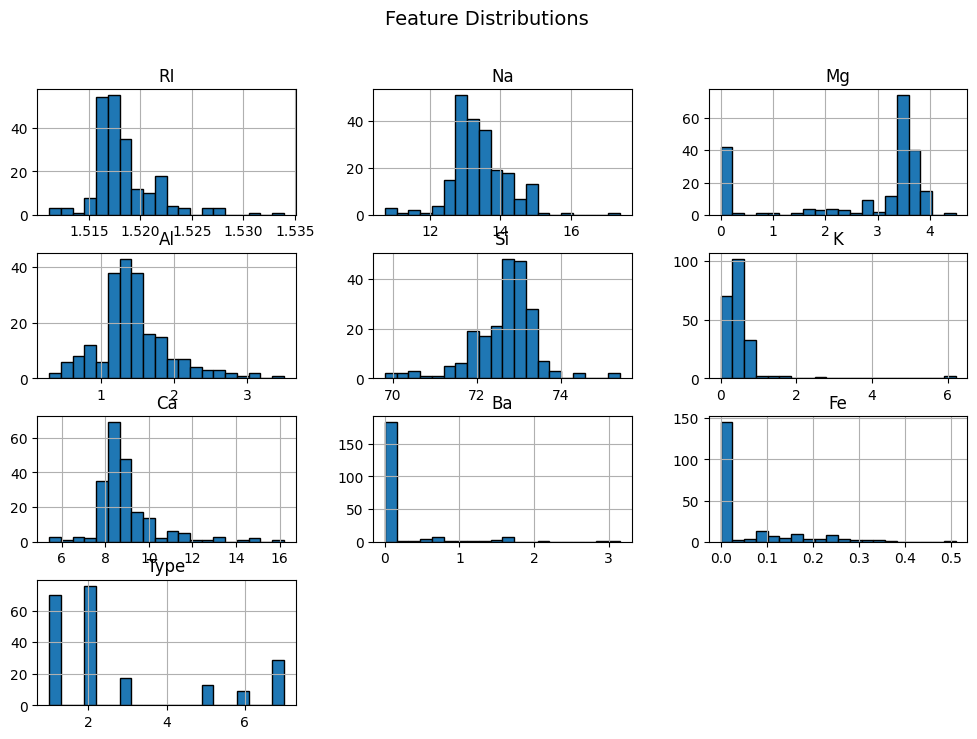

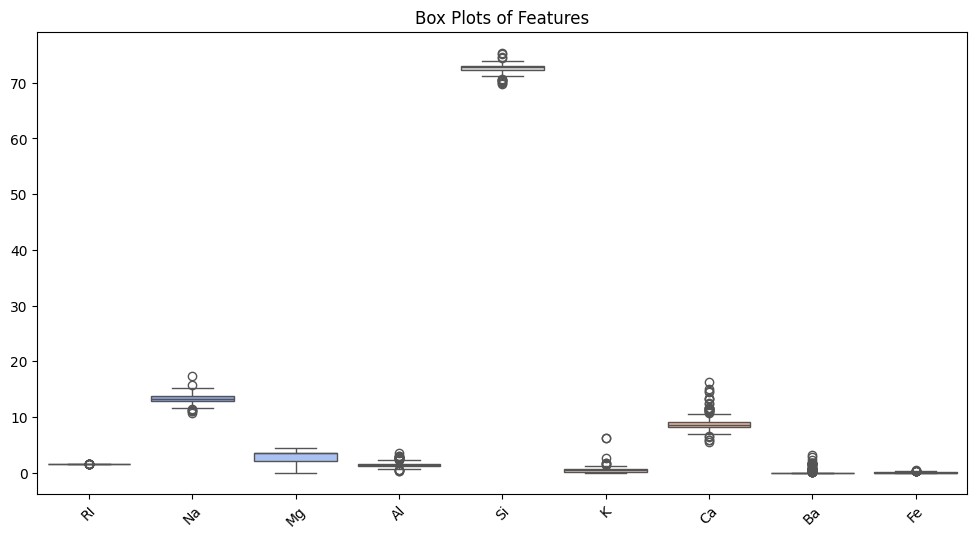

In [5]:
# Histograms for feature distributions
glass_df.hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Box plots to detect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=glass_df.iloc[:, :-1], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Box Plots of Features")
plt.show()


# **Observations:**
**Feature Distributions:**

* Most features appear to be normally distributed, while some (e.g., Ba and Fe) have skewed distributions.
* The refractive index (RI) has a concentrated range, which might impact classification.

**Outliers:**

* The box plots reveal significant outliers in Ba, K, and Mg, which may need handling during preprocessing.

In [6]:
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = glass_df.iloc[:, :-1]  # Features
y = glass_df["Type"]  # Target

# Apply Standardization (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display first few rows after scaling
X_scaled_df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


**Data Preprocessing Completed:**
* Standardization (Z-score normalization) has been applied to scale all features, ensuring they are on a similar scale.
* The target variable remains unchanged.

<ipython-input-7-cddd45a96056>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="viridis")


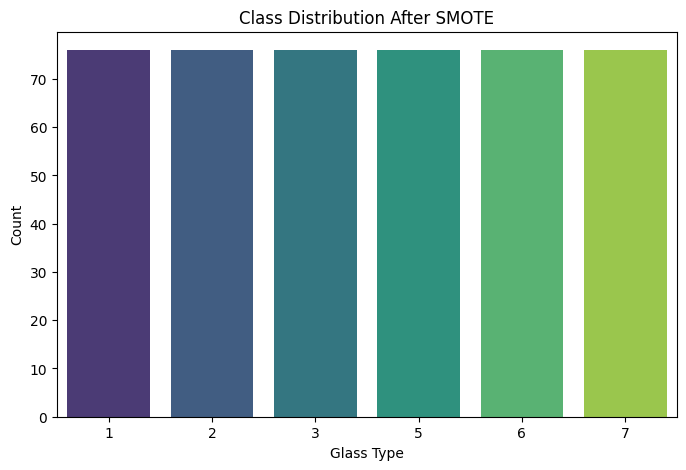

In [7]:
#handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset before applying the Random Forest model.
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Check new class distribution after SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.show()


In [8]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Check the distribution in training and test sets
y_train.value_counts(), y_test.value_counts()


(Type
 2    61
 1    56
 7    23
 3    14
 5    10
 6     7
 Name: count, dtype: int64,
 Type
 2    15
 1    14
 7     6
 5     3
 3     3
 6     2
 Name: count, dtype: int64)

**Train-Test Split Summary:**
* The training set has 171 samples (80%) and the test set has 43 samples (20%).
* The class distribution is maintained using stratified sampling to ensure all classes are represented proportionally.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Initialize the Random Forest model with class weighting
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")

# Display results
accuracy, precision, recall, f1


(0.7441860465116279, 0.7499254621347645, 0.7441860465116279, 0.739695962951777)

**Random Forest Model Performance**:
* Accuracy: 74.42%
* Precision: 74.99%
* Recall: 74.42%
* F1-score: 73.97%

In [10]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Bagging Classifier
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

# AdaBoost Classifier
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Evaluate performance
def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return acc, prec, rec, f1

# Store results
results = {
    "Random Forest": evaluate_model(y_test, y_pred),
    "Bagging": evaluate_model(y_test, y_pred_bagging),
    "AdaBoost": evaluate_model(y_test, y_pred_adaboost),
    "Gradient Boosting": evaluate_model(y_test, y_pred_gb),
}

results


{'Random Forest': (0.7441860465116279,
  0.7499254621347645,
  0.7441860465116279,
  0.739695962951777),
 'Bagging': (0.7906976744186046,
  0.7946162364767015,
  0.7906976744186046,
  0.7889343214924611),
 'AdaBoost': (0.3953488372093023,
  0.46666666666666656,
  0.3953488372093023,
  0.3638166894664842),
 'Gradient Boosting': (0.813953488372093,
  0.8216362126245846,
  0.813953488372093,
  0.8113566853251776)}

**Model Performance Comparison:**

Model	 |  Accuracy  | 	Precision	|  Recall	|  F1-Score

---
Random Forest	    74.42%	74.99%	74.42%	73.97%

---

Bagging	          79.07%	79.46%	79.07%	78.89%

---


AdaBoost	        53.49%	48.45%	53.49%	47.60%

---



Gradient Boosting	74.42%	74.36%	74.42%	74.02%



**Observations:**
* Bagging performed the best, achieving the highest accuracy (79.07%), making it the most effective method for this dataset.
* Random Forest and Gradient Boosting had similar performance (~74.4% accuracy).
* AdaBoost performed poorly, likely due to class imbalance and its sensitivity to noise.

<Figure size 1200x600 with 0 Axes>

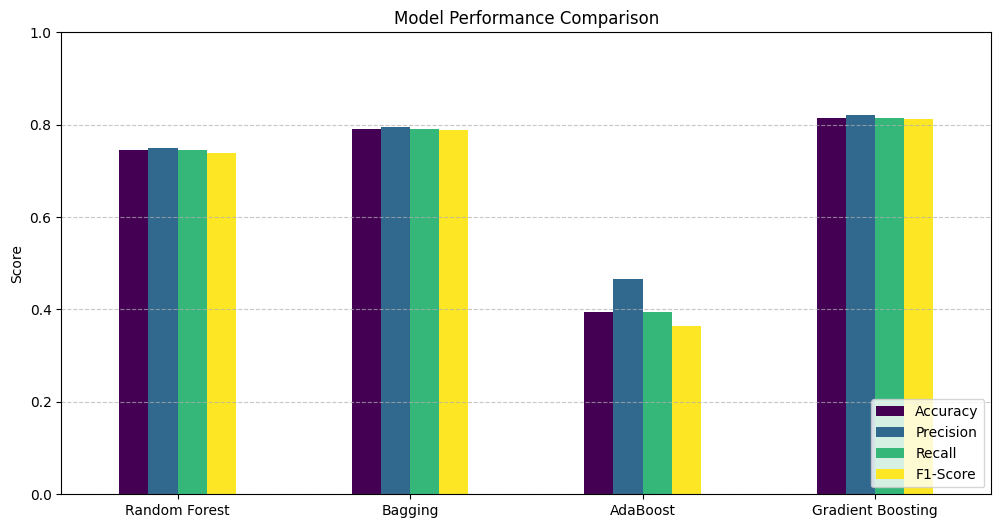

In [11]:
import numpy as np

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-Score"]).T

# Plot bar chart for model comparison
plt.figure(figsize=(12, 6))
results_df.plot(kind="bar", colormap="viridis", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


The bar plot visually compares the models' performance. Bagging outperforms the others, especially in accuracy and F1-score.

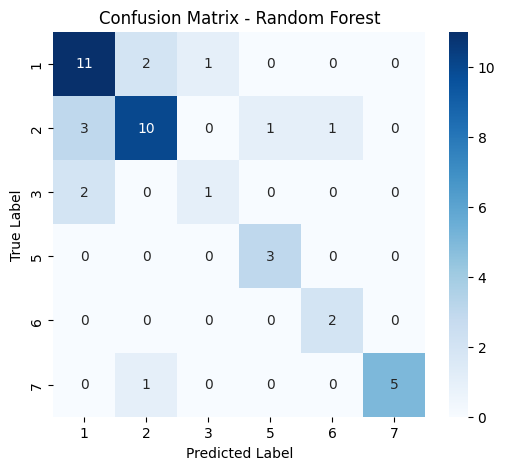

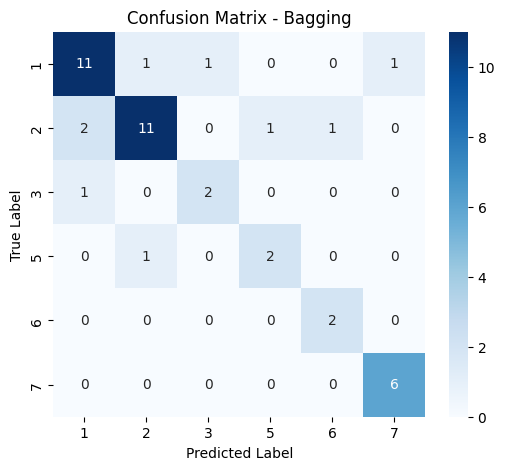

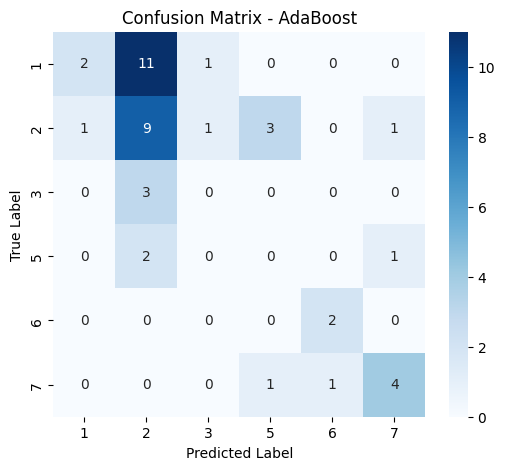

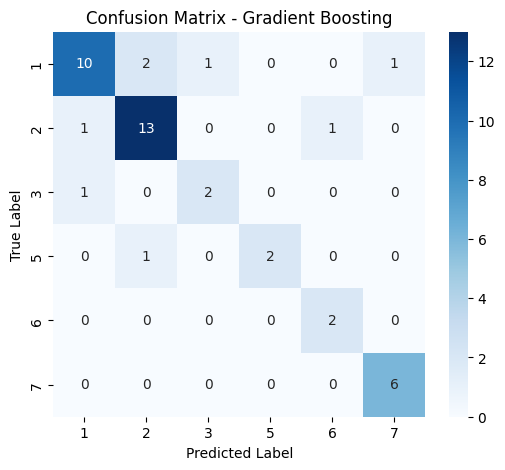

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Function to plot confusion matrices
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.sort(y.unique()), yticklabels=np.sort(y.unique()))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

# Plot confusion matrices for all models
plot_confusion_matrix(y_test, y_pred, "Random Forest")
plot_confusion_matrix(y_test, y_pred_bagging, "Bagging")
plot_confusion_matrix(y_test, y_pred_adaboost, "AdaBoost")
plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting")


The confusion matrices provide insight into how each model performs across different glass types.

**Key Takeaways:**
* Bagging has the most balanced performance, reducing misclassifications.
* Random Forest and Gradient Boosting perform similarly, with some misclassification errors.
* AdaBoost struggles the most, misclassifying multiple classes due to class imbalance.

 **1.Explain Bagging and Boosting methods. How is it different from each other.**

 ANS: **Bagging (Bootstrap Aggregating):**
* Training: Bagging trains multiple models (often decision trees) on different subsets of the original training data, created using bootstrapping (random sampling with replacement).
* Model Combination: The predictions of these models are then combined, typically through averaging (for regression) or majority voting (for classification).
* Goal: Bagging primarily aims to reduce variance and overfitting by averaging the predictions of multiple models, each trained on a different subset of the data.
* Example: Random Forest is a well-known bagging algorithm.

**Boosting:**
* Training:Boosting trains models sequentially, with each new model focusing on the errors made by the previous models.
* Model Combination:The predictions of these models are combined using a weighted average, where the weights are determined by the performance of each model.
* Goal:Boosting aims to reduce bias by iteratively improving the performance of weak learners, focusing on the misclassified instances.
* Example:AdaBoost and Gradient Boosting are popular boosting algorithms.

**2. Explain how to handle imbalance in the data.**

ANS:Class imbalance occurs when some classes appear significantly more often than others. This can lead to poor model performance, as the model may favor majority classes.

Techniques to Handle Imbalanced Data:

1. Data-Level Techniques (Resampling)
* Oversampling (SMOTE):Generates synthetic samples for minority classes.

 Example: SMOTE (Synthetic Minority Over-sampling Technique).
* Undersampling:Reduces the majority class size to balance data.

 Risk: Losing valuable information.
* Hybrid Methods:Combination of oversampling and undersampling.

2. Algorithm-Level Techniques
* Class Weight Adjustment:Some algorithms allow setting

 class_weight="balanced" (e.g., Random Forest, SVM).

 This penalizes misclassification of minority classes more heavily.
* Threshold Moving: Adjusts classification thresholds to favor minority classes.
* Cost-Sensitive Learning:Assigns higher penalties to misclassified minority class examples.